# 05 - XGBoost and Tree Models

## Goal
Build an XGBoost inflation-nowcasting baseline in a notebook-first workflow, then compare two lag-window tabular representations:

1. **`mean_pooled`**: average each feature across the lookback window.
2. **`flattened`**: keep all lagged values as separate columns (`feature_lagK`) to preserve temporal detail.

This notebook keeps the project conventions from earlier notebooks:
- monthly chronological split logic from notebook 02 (`70/15/15` with lag windows),
- default lag length of `60` months,
- deterministic seeds,
- metrics `MAE`, `sMAPE`, and `MASE`,
- artifacts saved under `results/xgb/`.


In [1]:

from pathlib import Path
import sys
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.project_utils import ensure_project_dirs, seed_everything

seed_everything(42)
np.random.seed(42)

paths = ensure_project_dirs()
xgb_dir = paths["results"] / "xgb"
xgb_dir.mkdir(parents=True, exist_ok=True)

METRICS_PATH = xgb_dir / "metrics.json"
PREDS_PLOT_PATH = xgb_dir / "preds_vs_actuals.png"
LEARNING_CURVE_PATH = xgb_dir / "learning_curve.png"
FEATURE_IMPORTANCE_JSON_PATH = xgb_dir / "feature_importance.json"
FEATURE_IMPORTANCE_PLOT_PATH = xgb_dir / "feature_importance.png"

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_columns = 200

print("Repo root:", ROOT)
print("XGBoost version:", xgb.__version__)
print("Results dir:", xgb_dir)


Repo root: C:\Users\jijos\Desktop\261-Project
XGBoost version: 3.1.3
Results dir: C:\Users\jijos\Desktop\261-Project\results\xgb



## Config

The hyperparameters are intentionally conservative and close to a classical tabular XGBoost baseline, with early stopping on validation data.

Selection rule for representation:
- choose the representation with lowest **validation MAE** (to avoid test leakage),
- report test metrics for both representations as supporting evidence.


In [2]:

CONFIG = {
    "seed": 42,
    "lag_length": 24,
    "target_mode": "delta",  # options: "level", "delta"
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "mase_m": 1,
    "candidate_representations": ["mean_pooled", "flattened"],
    "selection_metric": "val_mae",
    "xgb": {
        "objective": "reg:squarederror",
        "n_estimators": 1400,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 3,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_lambda": 2.0,
        "reg_alpha": 0.1,
        "gamma": 0.0,
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": 1,
        "eval_metric": ["mae", "rmse"],
        "early_stopping_rounds": 60,
    },
}

if CONFIG["lag_length"] <= 0:
    raise ValueError("lag_length must be positive")
if CONFIG["target_mode"] not in {"level", "delta"}:
    raise ValueError("target_mode must be 'level' or 'delta'")

print(json.dumps(CONFIG, indent=2))


{
  "seed": 42,
  "lag_length": 24,
  "target_mode": "delta",
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "mase_m": 1,
  "candidate_representations": [
    "mean_pooled",
    "flattened"
  ],
  "selection_metric": "val_mae",
  "xgb": {
    "objective": "reg:squarederror",
    "n_estimators": 1400,
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 3,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_lambda": 2.0,
    "reg_alpha": 0.1,
    "gamma": 0.0,
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": 1,
    "eval_metric": [
      "mae",
      "rmse"
    ],
    "early_stopping_rounds": 60
  }
}



## Load Processed Data and Metadata

Notebook 02 stores:
- `data/processed/split_metadata.json`
- `data/processed/modeling_table_<feature_set>.csv`

We reuse these to guarantee split consistency across models.


In [3]:

split_meta_path = paths["processed_data"] / "split_metadata.json"
if not split_meta_path.exists():
    raise FileNotFoundError("Missing split metadata. Run notebook 02_feature_engineering_and_splits.ipynb first.")

split_meta = json.loads(split_meta_path.read_text(encoding="utf-8"))

if split_meta.get("feature_set"):
    preferred_model_path = paths["processed_data"] / f"modeling_table_{split_meta['feature_set']}.csv"
else:
    preferred_model_path = paths["processed_data"] / "modeling_table_full.csv"

if preferred_model_path.exists():
    model_table_path = preferred_model_path
else:
    candidates = sorted(paths["processed_data"].glob("modeling_table_*.csv"))
    if not candidates:
        raise FileNotFoundError("No modeling_table_*.csv found. Run notebook 02 first.")
    model_table_path = candidates[0]

model_df = pd.read_csv(model_table_path, index_col=0, parse_dates=True).sort_index()

TARGET_NAME = split_meta.get("target_name")
if TARGET_NAME is None:
    raise KeyError("target_name missing in split_metadata.json")
if TARGET_NAME not in model_df.columns:
    raise KeyError(f"Target column {TARGET_NAME!r} is missing from {model_table_path}")

selected_features = split_meta.get("selected_features")
if selected_features:
    selected_features = [c for c in selected_features if c in model_df.columns and c != TARGET_NAME]
else:
    selected_features = [c for c in model_df.columns if c != TARGET_NAME]

if len(selected_features) == 0:
    raise ValueError("No usable feature columns were found.")

train_end = int(split_meta["boundaries"]["train_end_idx"])
val_end = int(split_meta["boundaries"]["val_end_idx"])

if not (0 < train_end < val_end < len(model_df)):
    raise ValueError("Invalid split boundaries in split metadata")
if CONFIG["lag_length"] >= train_end:
    raise ValueError(f"lag_length={CONFIG['lag_length']} is too large for train split size={train_end}")

X_df = model_df[selected_features].copy()
y_sr = model_df[TARGET_NAME].copy()

print("Model table:", model_table_path)
print("Rows:", len(model_df), "| Features:", len(selected_features))
print("Target:", TARGET_NAME)
print("Split boundaries (row indices):", {"train_end": train_end, "val_end": val_end})
print("Date range:", model_df.index.min().date(), "to", model_df.index.max().date())


Model table: C:\Users\jijos\Desktop\261-Project\data\processed\modeling_table_full.csv
Rows: 395 | Features: 22
Target: target_yoy_t_plus_1
Split boundaries (row indices): {'train_end': 347, 'val_end': 371}
Date range: 1993-01-01 to 2026-01-01



## Window Builder, Metrics, and Training Helpers

The helper functions below keep representation generation explicit and make feature-name mapping deterministic.


In [4]:

def mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))


def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom))


def mase(y_true, y_pred, y_insample, m=1, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_insample = np.asarray(y_insample)
    if len(y_insample) <= m:
        return float("nan")
    scale = np.mean(np.abs(y_insample[m:] - y_insample[:-m]))
    return float(np.mean(np.abs(y_true - y_pred)) / (scale + eps))


def evaluate_metrics(y_true, y_pred, y_insample, mase_m=1):
    return {
        "mae": mae(y_true, y_pred),
        "smape": smape(y_true, y_pred),
        "mase": mase(y_true, y_pred, y_insample, m=mase_m),
    }


def make_flattened_names(base_features, n_lags):
    names = []
    # lag{n_lags} is oldest; lag1 is most recent month before prediction time.
    for lag in range(n_lags, 0, -1):
        for feature in base_features:
            names.append(f"{feature}_lag{lag}")
    return names


def build_tabular_windows(X_df, y_sr, n_lags=60, representation="mean_pooled"):
    if representation not in {"mean_pooled", "flattened"}:
        raise ValueError("representation must be 'mean_pooled' or 'flattened'")

    if "Inflation_prev" not in X_df.columns:
        raise KeyError("Inflation_prev must exist in features for delta target mode")

    base_features = list(X_df.columns)
    X_vals = X_df.to_numpy(dtype=np.float32)
    y_vals = y_sr.to_numpy(dtype=np.float32)
    prev_vals = X_df["Inflation_prev"].to_numpy(dtype=np.float32)
    idx_vals = X_df.index

    if representation == "mean_pooled":
        out_columns = base_features
    else:
        out_columns = make_flattened_names(base_features, n_lags)

    X_out = []
    y_out = []
    p_out = []
    idx_out = []

    for i in range(n_lags, len(X_df)):
        block = X_vals[i - n_lags : i, :]
        if representation == "mean_pooled":
            feat = block.mean(axis=0)
        else:
            feat = block.reshape(-1)

        X_out.append(feat)
        y_out.append(y_vals[i])
        p_out.append(prev_vals[i])
        idx_out.append(idx_vals[i])

    X_window = pd.DataFrame(X_out, columns=out_columns, index=pd.Index(idx_out, name="date"))
    y_window = pd.Series(y_out, index=X_window.index, name=y_sr.name, dtype=np.float32)
    p_window = pd.Series(p_out, index=X_window.index, name="Inflation_prev", dtype=np.float32)

    return X_window, y_window, p_window


def split_windows_by_metadata_boundaries(X_window, y_window, p_window, full_index, train_end_idx, val_end_idx):
    train_boundary_date = full_index[train_end_idx]
    val_boundary_date = full_index[val_end_idx]

    train_mask = X_window.index < train_boundary_date
    val_mask = (X_window.index >= train_boundary_date) & (X_window.index < val_boundary_date)
    test_mask = X_window.index >= val_boundary_date

    split = {
        "X_train": X_window.loc[train_mask],
        "y_train": y_window.loc[train_mask],
        "p_train": p_window.loc[train_mask],
        "X_val": X_window.loc[val_mask],
        "y_val": y_window.loc[val_mask],
        "p_val": p_window.loc[val_mask],
        "X_test": X_window.loc[test_mask],
        "y_test": y_window.loc[test_mask],
        "p_test": p_window.loc[test_mask],
        "train_boundary_date": train_boundary_date,
        "val_boundary_date": val_boundary_date,
    }

    if len(split["X_train"]) == 0 or len(split["X_val"]) == 0 or len(split["X_test"]) == 0:
        raise ValueError("One of train/val/test window splits is empty. Check lag length and data coverage.")

    # Strict chronology checks.
    if not (split["X_train"].index.max() < split["X_val"].index.min()):
        raise AssertionError("Train/val chronology violated")
    if not (split["X_val"].index.max() < split["X_test"].index.min()):
        raise AssertionError("Val/test chronology violated")

    return split


def train_one_representation(rep_name, X_df, y_sr, train_end, val_end, config):
    X_window, y_window, p_window = build_tabular_windows(
        X_df=X_df,
        y_sr=y_sr,
        n_lags=config["lag_length"],
        representation=rep_name,
    )

    split = split_windows_by_metadata_boundaries(
        X_window=X_window,
        y_window=y_window,
        p_window=p_window,
        full_index=y_sr.index,
        train_end_idx=train_end,
        val_end_idx=val_end,
    )

    if config["target_mode"] == "delta":
        y_train_fit = split["y_train"].values - split["p_train"].values
        y_val_fit = split["y_val"].values - split["p_val"].values
    else:
        y_train_fit = split["y_train"].values
        y_val_fit = split["y_val"].values

    xgb_params = dict(config["xgb"])
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(
        split["X_train"],
        y_train_fit,
        eval_set=[(split["X_train"], y_train_fit), (split["X_val"], y_val_fit)],
        verbose=False,
    )

    best_iteration = int(model.best_iteration) if model.best_iteration is not None else int(config["xgb"]["n_estimators"] - 1)
    n_estimators_best = best_iteration + 1

    y_val_pred_raw = model.predict(split["X_val"], iteration_range=(0, n_estimators_best))
    if config["target_mode"] == "delta":
        y_val_pred = split["p_val"].values + y_val_pred_raw
    else:
        y_val_pred = y_val_pred_raw

    y_insample_val = y_sr.iloc[:train_end].values
    val_metrics = evaluate_metrics(split["y_val"].values, y_val_pred, y_insample=y_insample_val, mase_m=config["mase_m"])

    # Refit on train+val with representation-specific best number of trees, then score on held-out test.
    refit_params = dict(config["xgb"])
    refit_params["n_estimators"] = int(n_estimators_best)
    refit_params.pop("early_stopping_rounds", None)

    final_model = xgb.XGBRegressor(**refit_params)
    X_trainval = pd.concat([split["X_train"], split["X_val"]], axis=0)
    if config["target_mode"] == "delta":
        y_trainval = np.concatenate([
            split["y_train"].values - split["p_train"].values,
            split["y_val"].values - split["p_val"].values,
        ])
    else:
        y_trainval = pd.concat([split["y_train"], split["y_val"]], axis=0).values

    final_model.fit(X_trainval, y_trainval, verbose=False)

    y_test_pred_raw = final_model.predict(split["X_test"])
    if config["target_mode"] == "delta":
        y_test_pred = split["p_test"].values + y_test_pred_raw
    else:
        y_test_pred = y_test_pred_raw

    y_insample_test = y_sr.iloc[:val_end].values
    test_metrics = evaluate_metrics(split["y_test"].values, y_test_pred, y_insample=y_insample_test, mase_m=config["mase_m"])

    evals_result = model.evals_result()

    return {
        "representation": rep_name,
        "X_window": X_window,
        "y_window": y_window,
        "split": split,
        "model_train_val": model,
        "final_model": final_model,
        "best_iteration": int(best_iteration),
        "n_estimators_best": int(n_estimators_best),
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "evals_result": evals_result,
        "y_val_pred": y_val_pred,
        "y_test_pred": y_test_pred,
    }



## Train XGBoost on Both Representations

Each representation is trained and compared under the same split boundaries and base hyperparameters.


In [5]:

rep_results = {}
for rep_name in CONFIG["candidate_representations"]:
    rep_results[rep_name] = train_one_representation(
        rep_name=rep_name,
        X_df=X_df,
        y_sr=y_sr,
        train_end=train_end,
        val_end=val_end,
        config=CONFIG,
    )

comparison_rows = []
for rep_name, out in rep_results.items():
    row = {
        "representation": rep_name,
        "n_features_after_rep": int(out["X_window"].shape[1]),
        "n_train_windows": int(len(out["split"]["X_train"])),
        "n_val_windows": int(len(out["split"]["X_val"])),
        "n_test_windows": int(len(out["split"]["X_test"])),
        "best_iteration": int(out["best_iteration"]),
        "val_mae": float(out["val_metrics"]["mae"]),
        "val_smape": float(out["val_metrics"]["smape"]),
        "val_mase": float(out["val_metrics"]["mase"]),
        "test_mae": float(out["test_metrics"]["mae"]),
        "test_smape": float(out["test_metrics"]["smape"]),
        "test_mase": float(out["test_metrics"]["mase"]),
    }
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values(["val_mae", "test_mae"]).reset_index(drop=True)
winning_representation = comparison_df.iloc[0]["representation"]
winning_result = rep_results[winning_representation]

best_test_representation = comparison_df.sort_values("test_mae").iloc[0]["representation"]
selection_alignment = winning_representation == best_test_representation

print("Representation comparison (lower is better):")
display(comparison_df)
print("Selected representation (by validation MAE):", winning_representation)
print("Best representation on held-out test MAE:", best_test_representation)
print("Validation/Test winner alignment:", selection_alignment)


Representation comparison (lower is better):


,representation,n_features_after_rep,n_train_windows,n_val_windows,n_test_windows,best_iteration,val_mae,val_smape,val_mase,test_mae,test_smape,test_mase
0,mean_pooled,22,323,24,24,46,0.349306,7.446935,1.247526,0.169291,6.006873,0.585020
1,flattened,528,323,24,24,28,0.381628,7.314903,1.362964,0.174153,6.121748,0.601822


Selected representation (by validation MAE): mean_pooled
Best representation on held-out test MAE: mean_pooled
Validation/Test winner alignment: True



## Representation Choice and Tree-vs-Sequence Discussion

**Representation decision rule used here:** select the representation with the lowest validation MAE, then report held-out test metrics for transparency.

Why tree models can outperform sequence models in this project:
- Monthly macro datasets are small, and boosted trees often reach strong bias-variance tradeoffs with less data than deep sequence models.
- Feature engineering already encodes macro structure (deltas, YoY transforms, interactions, seasonality), which trees can exploit effectively without learning sequence dynamics from scratch.
- Trees are usually easier to regularize and diagnose quickly with validation curves and feature importance.

Why tree models can underperform sequence models:
- Flattened/pooled windows are hand-designed summaries and may miss long-horizon temporal motifs that sequence models can learn directly.
- Trees do not naturally preserve ordered hidden state like recurrent models.
- Regime shifts can still hurt boosted trees if engineered features and lag representation do not capture the new dynamics.


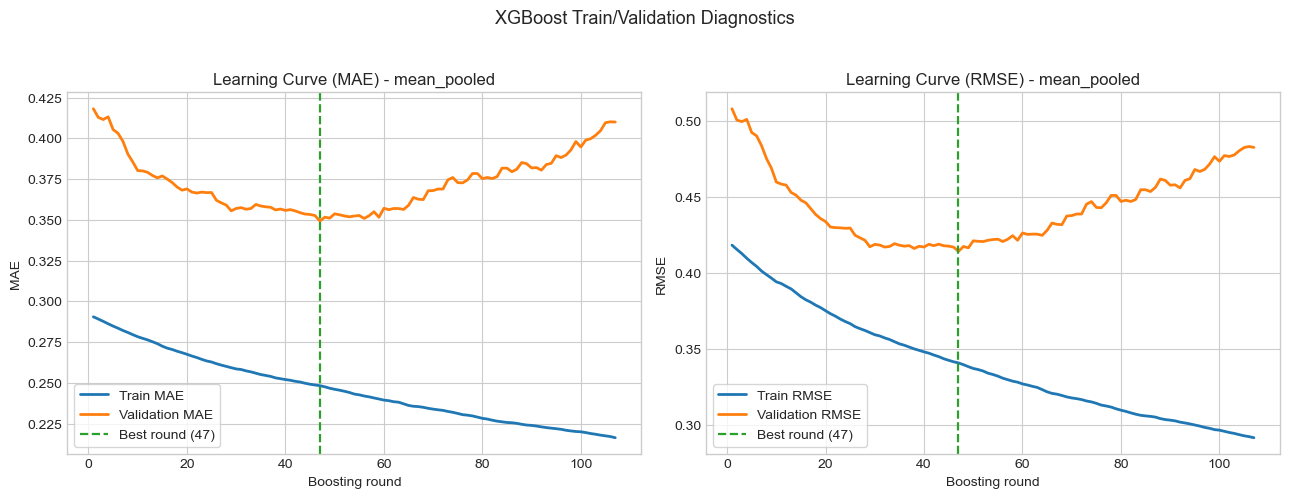

Saved: C:\Users\jijos\Desktop\261-Project\results\xgb\learning_curve.png


In [6]:

# Save learning-curve plot for the selected representation.
curves = winning_result["evals_result"]
train_mae_curve = curves["validation_0"]["mae"]
val_mae_curve = curves["validation_1"]["mae"]
train_rmse_curve = curves["validation_0"]["rmse"]
val_rmse_curve = curves["validation_1"]["rmse"]

rounds = np.arange(1, len(train_mae_curve) + 1)
best_round = winning_result["best_iteration"] + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(rounds, train_mae_curve, color="#1f77b4", linewidth=2.0, label="Train MAE")
axes[0].plot(rounds, val_mae_curve, color="#ff7f0e", linewidth=2.0, label="Validation MAE")
axes[0].axvline(best_round, linestyle="--", color="#2ca02c", linewidth=1.6, label=f"Best round ({best_round})")
axes[0].set_title(f"Learning Curve (MAE) - {winning_representation}")
axes[0].set_xlabel("Boosting round")
axes[0].set_ylabel("MAE")
axes[0].legend(frameon=True)

axes[1].plot(rounds, train_rmse_curve, color="#1f77b4", linewidth=2.0, label="Train RMSE")
axes[1].plot(rounds, val_rmse_curve, color="#ff7f0e", linewidth=2.0, label="Validation RMSE")
axes[1].axvline(best_round, linestyle="--", color="#2ca02c", linewidth=1.6, label=f"Best round ({best_round})")
axes[1].set_title(f"Learning Curve (RMSE) - {winning_representation}")
axes[1].set_xlabel("Boosting round")
axes[1].set_ylabel("RMSE")
axes[1].legend(frameon=True)

fig.suptitle("XGBoost Train/Validation Diagnostics", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(LEARNING_CURVE_PATH, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", LEARNING_CURVE_PATH)


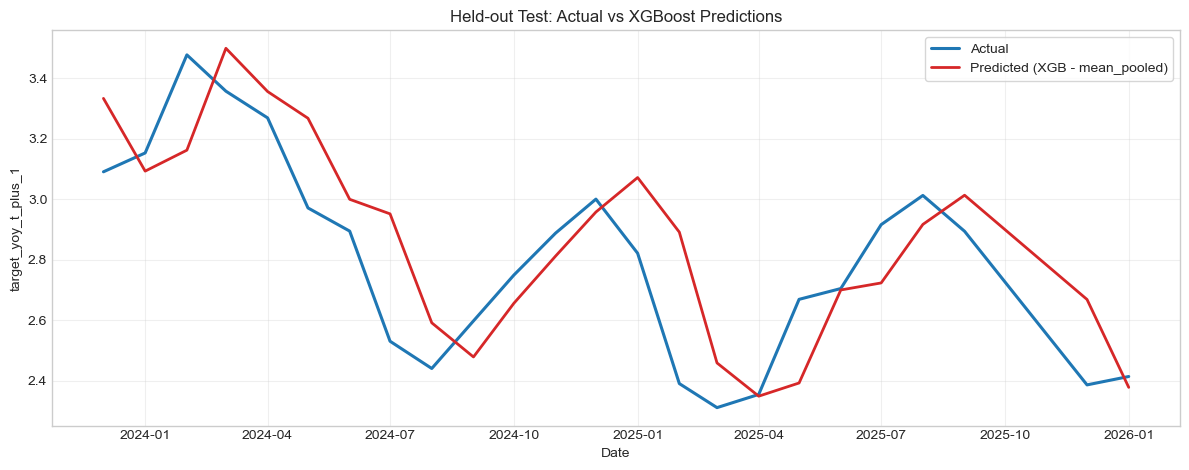

Saved: C:\Users\jijos\Desktop\261-Project\results\xgb\preds_vs_actuals.png


,actual,predicted
date,,
2023-12-01,3.090885,3.333500
2024-01-01,3.153171,3.093109
2024-02-01,3.477385,3.162366
2024-03-01,3.357364,3.499127
2024-04-01,3.269029,3.356186


In [7]:

# Save predictions-vs-actuals plot for held-out test.
pred_df = pd.DataFrame(
    {
        "actual": winning_result["split"]["y_test"].values,
        "predicted": winning_result["y_test_pred"],
    },
    index=winning_result["split"]["X_test"].index,
).sort_index()

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(pred_df.index, pred_df["actual"], linewidth=2.2, color="#1f77b4", label="Actual")
ax.plot(pred_df.index, pred_df["predicted"], linewidth=2.0, color="#d62728", label=f"Predicted (XGB - {winning_representation})")
ax.set_title("Held-out Test: Actual vs XGBoost Predictions")
ax.set_xlabel("Date")
ax.set_ylabel(TARGET_NAME)
ax.legend(frameon=True)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(PREDS_PLOT_PATH, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", PREDS_PLOT_PATH)
pred_df.head()


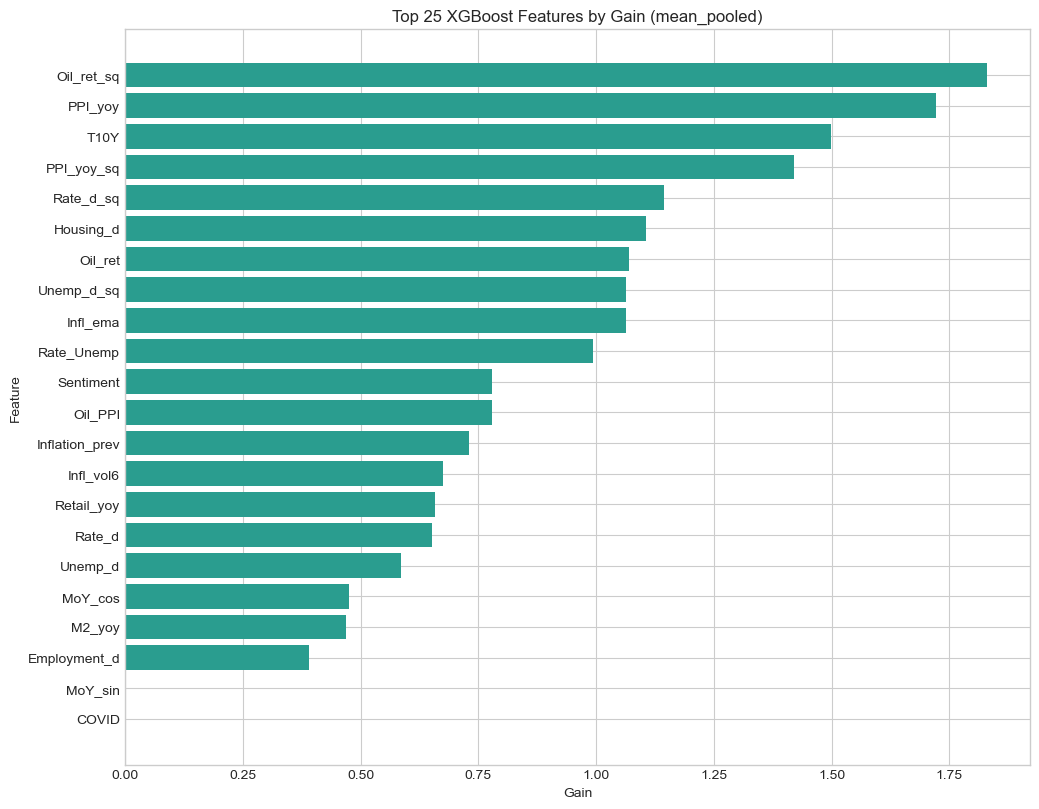

Saved: C:\Users\jijos\Desktop\261-Project\results\xgb\feature_importance.json
Saved: C:\Users\jijos\Desktop\261-Project\results\xgb\feature_importance.png


,feature,base_feature,gain,weight,cover
0,Oil_ret_sq,Oil_ret_sq,1.829469,53.0,210.641510
1,PPI_yoy,PPI_yoy,1.720673,33.0,210.848480
2,T10Y,T10Y,1.497673,7.0,33.571430
3,PPI_yoy_sq,PPI_yoy_sq,1.420895,16.0,229.812500
4,Rate_d_sq,Rate_d_sq,1.144302,8.0,68.500000
5,Housing_d,Housing_d,1.104847,21.0,90.190475
6,Oil_ret,Oil_ret,1.070785,34.0,68.147057
7,Unemp_d_sq,Unemp_d_sq,1.064353,4.0,147.000000
8,Infl_ema,Infl_ema,1.063033,26.0,114.269234
9,Rate_Unemp,Rate_Unemp,0.993581,15.0,118.533333


In [8]:

# Feature importance with explicit names (no anonymous f0/f1 indices).
booster = winning_result["final_model"].get_booster()
feature_names = list(winning_result["split"]["X_train"].columns)

importance_gain = booster.get_score(importance_type="gain")
importance_weight = booster.get_score(importance_type="weight")
importance_cover = booster.get_score(importance_type="cover")

def map_base_feature(feature_name, rep_name):
    if rep_name == "flattened" and "_lag" in feature_name:
        return feature_name.rsplit("_lag", 1)[0]
    return feature_name

importance_rows = []
for feat in feature_names:
    base_feat = map_base_feature(feat, winning_representation)
    importance_rows.append(
        {
            "feature": feat,
            "base_feature": base_feat,
            "gain": float(importance_gain.get(feat, 0.0)),
            "weight": float(importance_weight.get(feat, 0.0)),
            "cover": float(importance_cover.get(feat, 0.0)),
        }
    )

importance_df = pd.DataFrame(importance_rows).sort_values("gain", ascending=False).reset_index(drop=True)

# Verification: ensure all feature names map back to engineered feature families.
unmapped_base_features = sorted(set(importance_df["base_feature"]) - set(selected_features))
if unmapped_base_features:
    raise AssertionError(f"Feature importance mapping failed for: {unmapped_base_features}")

anonymous_name_pattern = importance_df["feature"].str.fullmatch(r"f\d+").fillna(False)
if bool(anonymous_name_pattern.any()):
    raise AssertionError("Anonymous XGBoost feature names detected (f0/f1...).")

importance_payload = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "representation": winning_representation,
    "importance_type_primary": "gain",
    "n_total_features": int(len(importance_df)),
    "n_nonzero_gain_features": int((importance_df["gain"] > 0).sum()),
    "feature_name_mapping_note": (
        "mean_pooled keeps original engineered feature names; "
        "flattened uses <feature>_lagK where lag1 is most recent month."
    ),
    "top_features_by_gain": importance_df.head(50).to_dict(orient="records"),
    "all_features": importance_df.to_dict(orient="records"),
}
FEATURE_IMPORTANCE_JSON_PATH.write_text(json.dumps(importance_payload, indent=2), encoding="utf-8")

plot_top_n = 25
plot_df = importance_df.head(plot_top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(10.5, 8.2))
ax.barh(plot_df["feature"], plot_df["gain"], color="#2a9d8f")
ax.set_title(f"Top {plot_top_n} XGBoost Features by Gain ({winning_representation})")
ax.set_xlabel("Gain")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(FEATURE_IMPORTANCE_PLOT_PATH, dpi=170, bbox_inches="tight")
plt.show()

print("Saved:", FEATURE_IMPORTANCE_JSON_PATH)
print("Saved:", FEATURE_IMPORTANCE_PLOT_PATH)
importance_df.head(15)


In [9]:
# Save metrics and complete verification checks.
metrics_payload = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "target_name": TARGET_NAME,
    "data": {
        "modeling_table": str(model_table_path.relative_to(ROOT)),
        "n_rows": int(len(model_df)),
        "n_engineered_features": int(len(selected_features)),
        "lag_length": int(CONFIG["lag_length"]),
        "train_end_idx": int(train_end),
        "val_end_idx": int(val_end),
        "test_start": str(winning_result["split"]["X_test"].index.min().date()),
        "test_end": str(winning_result["split"]["X_test"].index.max().date()),
    },
    "target_mode": CONFIG["target_mode"],
    "xgboost_config": CONFIG["xgb"],
    "selection_rule": "Lowest validation MAE; test metrics reported as out-of-sample evidence.",
    "representation_comparison": comparison_df.to_dict(orient="records"),
    "selected_representation": winning_representation,
    "selected_representation_metrics": {
        "validation": winning_result["val_metrics"],
        "test": winning_result["test_metrics"],
    },
    "selection_alignment_with_test_mae": bool(selection_alignment),
    "learning_curve_summary": {
        "best_iteration_zero_based": int(winning_result["best_iteration"]),
        "best_round_one_based": int(winning_result["best_iteration"] + 1),
        "best_validation_mae": float(np.min(val_mae_curve)),
        "best_validation_rmse": float(np.min(val_rmse_curve)),
        "train_mae_by_round": [float(v) for v in train_mae_curve],
        "validation_mae_by_round": [float(v) for v in val_mae_curve],
        "train_rmse_by_round": [float(v) for v in train_rmse_curve],
        "validation_rmse_by_round": [float(v) for v in val_rmse_curve],
    },
    "artifacts": {
        "metrics": str(METRICS_PATH.relative_to(ROOT)),
        "preds_vs_actuals_plot": str(PREDS_PLOT_PATH.relative_to(ROOT)),
        "learning_curve_plot": str(LEARNING_CURVE_PATH.relative_to(ROOT)),
        "feature_importance_json": str(FEATURE_IMPORTANCE_JSON_PATH.relative_to(ROOT)),
        "feature_importance_plot": str(FEATURE_IMPORTANCE_PLOT_PATH.relative_to(ROOT)),
    },
}
METRICS_PATH.write_text(json.dumps(metrics_payload, indent=2), encoding="utf-8")

required_artifacts = {
    "metrics": METRICS_PATH,
    "preds_vs_actuals": PREDS_PLOT_PATH,
    "learning_curve": LEARNING_CURVE_PATH,
    "feature_importance_json": FEATURE_IMPORTANCE_JSON_PATH,
    "feature_importance_plot": FEATURE_IMPORTANCE_PLOT_PATH,
}

print("Artifact checks:")
for name, p in required_artifacts.items():
    print(f"- {name}: {p} | exists={p.exists()}")

if not all(p.exists() for p in required_artifacts.values()):
    raise AssertionError("One or more required artifacts are missing.")

# Explicit required confirmations.
print()
print("Winner by validation MAE:", winning_representation)
print("Feature importance names mapped back to engineered features:", len(unmapped_base_features) == 0)
print("Anonymous f0/f1 names avoided:", not bool(anonymous_name_pattern.any()))

if len(unmapped_base_features) != 0:
    raise AssertionError("Feature importance base-feature mapping is incomplete.")
if bool(anonymous_name_pattern.any()):
    raise AssertionError("Feature importance contains anonymous names.")

print()
print("Saved metrics:", METRICS_PATH)
print("Final test metrics (selected representation):")
print(json.dumps(winning_result["test_metrics"], indent=2))

Artifact checks:
- metrics: C:\Users\jijos\Desktop\261-Project\results\xgb\metrics.json | exists=True
- preds_vs_actuals: C:\Users\jijos\Desktop\261-Project\results\xgb\preds_vs_actuals.png | exists=True
- learning_curve: C:\Users\jijos\Desktop\261-Project\results\xgb\learning_curve.png | exists=True
- feature_importance_json: C:\Users\jijos\Desktop\261-Project\results\xgb\feature_importance.json | exists=True
- feature_importance_plot: C:\Users\jijos\Desktop\261-Project\results\xgb\feature_importance.png | exists=True

Winner by validation MAE: mean_pooled
Feature importance names mapped back to engineered features: True
Anonymous f0/f1 names avoided: True

Saved metrics: C:\Users\jijos\Desktop\261-Project\results\xgb\metrics.json
Final test metrics (selected representation):
{
  "mae": 0.16929061710834503,
  "smape": 6.006872653961182,
  "mase": 0.5850202584195688
}
